# Data 612 Final Project

Matthew Tillmawitz

## Introduction

For this project we will be building and comparing several recommenders trained on the Amazon Reviews '23 Software dataset from the University of California San Diego found [here](https://amazon-reviews-2023.github.io/index.html), the citation for which can be found at the end of this project. We will use PyTorch and PyTorch Lightning to build our models as both tools are highly performant and are gaining widespread use in industry. The models will be trained using Google Colab to host this notebook to meet the requirements of Project 6 as well as to gain access to GPUs to allow for larger models to be trained quickly. We will explore the performance of three different model types: a simple matrix factorization model, a neural collaborative filtering model, and a two tower model as well as explore the impact of different negative sampling techniques on the quality of recommendations these models provide. The models will be trained using only the user, item, rating triplets as input, as exploring the impact of additional features generated from sources such as item descriptions or review text was omitted to keep the scope of the project reasonable.

# Model Architectures

The three model architectures we will be exploring are examples of the differing levels of complexity that can be present in recommenders. A brief overview of the high level architecture of each is included to provide context. It should be noted, due to the loss functions being used to train the models the activation functions are omitted in the diagrams. Instead, the activation function is applied to the output of a given model whenever a prediction is made. The descriptions of the models are within the context of user, item, rating triplets as the only training data and it should be noted additional features could be created and used with all three model types.

In [36]:
#!pip install pytorch_lightning mermaid-py

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint, DeviceStatsMonitor
from pytorch_lightning.loggers import CSVLogger
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from torchmetrics.retrieval import RetrievalNormalizedDCG, RetrievalRecall, RetrievalPrecision
from torch.optim import AdamW
from typing import Dict, List, Optional, Tuple, Union
from mermaid import Mermaid

### Matrix Factorization

This relatively simple model type is being used as a baseline for comparison due to the very good performance it is able to achieve and relatively high interpretability compared to more complex models. The user-item interaction matrix R is factored into a matrix representing user features U and another representing item features I such that R = U x I^T. The dimensions of the user and item matrices are determined by the number of users/items and another arbitrary dimension which is the number of latent factors used. A prediction for a given user-item pairing can then be made by calculating the dot product of the user and item factor vectors. The number of latent factors is one potential tuning parameter for these models. The values initial values for the user and item matrices are randomly seeded and tuned iteratively based on the gradient of the chosen loss function.

In [38]:
mf_diagram = """
graph LR
    A[User ID: 123] --> B[User Embedding Matrix]
    C[Item ID: 456] --> D[Item Embedding Matrix]

    B --> E[Combine<br> u x i]
    D --> E

    E --> F[Prediction Score]
"""

Mermaid(mf_diagram)

### Neural Collaborative Filtering

Matrix factorization models can have difficulty dealing with non-linear decision boundaries and can face overfitting if too many features are included, both latent and those generated from content like descriptions, genres, or lyrics. Neural Collaborative Filtering attempts to address this by combining traditional matrix factorization with a neural network. There are separate user and item embeddings for the matrix factorization and neural network components to allow for each branch of the model to perform optimally. The matrix factorization branch behaves as above, except the cross product of the user and item vectors is used instead of the dot product. Seperate embeddings representing a given user and item are passed through a neural network in parallel, and the outputs of both the neural network and matrix factorization are passed to a final network layer which generates a single output. This would normally be passed to an activation function such as a sigmoid, however the loss function chosen necessitates this happen after the model is trained. During training the different user and item embeddings are tuned as well as the weights in the various layers of the neural network components.

In [39]:
better_ncf = """
graph LR
    %% Input layer
    A[User ID: 123] --> B[User Embedding GMF]
    A --> C[User Embedding MLP]
    D[Item ID: 456] --> E[Item Embedding GMF]
    D --> F[Item Embedding MLP]

    %% GMF Path - Generalized Matrix Factorization
    B --> G[Element-wise Product<br/>user_gmf x item_gmf]
    E --> G

    %% MLP Path - Multi-Layer Perceptron
    C --> H[Combine<br/>user_mlp + item_mlp]
    F --> H
    H --> I[Hidden Layer 1]
    I --> J[....]
    J --> K[Final Hidden Layer]

    %% Fusion Layer
    G --> L[Combine GMF + MLP<br>Outputs]
    K --> L

    %% Final Prediction
    L --> M[Final Dense Layer<br/>to single output]
    M --> N[Prediction Score]

    %% Styling
    classDef inputNode fill:#e1f5fe,stroke:#0277bd,stroke-width:2px
    classDef embedding fill:#f3e5f5,stroke:#7b1fa2,stroke-width:2px
    classDef gmfPath fill:#e8f5e8,stroke:#388e3c,stroke-width:2px
    classDef mlpPath fill:#fff8e1,stroke:#ff8f00,stroke-width:2px
    classDef fusion fill:#fff3e0,stroke:#f57c00,stroke-width:2px
    classDef output fill:#ffebee,stroke:#d32f2f,stroke-width:2px

    class A,D inputNode
    class B,C,E,F embedding
    class G gmfPath
    class H,I,J,K mlpPath
    class L,M fusion
    class N output
"""

Mermaid(better_ncf)

### Two Tower

Two Tower models are very common in industry due to the speed with which predictions can be generated at scale. User and item specific embeddings are used to represent each, and each is passed through a separate neural network referred to as a "tower". The outputs of each tower are combined ans used at the input for a final prediction layer which generates a score. As for the NCF model, this is normally passed through an activation function which is omitted here. The separate towers allow for users and items to be processed in parallel in production, leading to a high level of scalability and parallelism which makes this model very popular. During training both the embeddings and the network layers are tuned as with NCF.

In [40]:
better_tt = """
graph LR
    %% Input layer
    A[User ID: 123] --> B[Lookup User Embedding Table]
    C[Item ID: 456] --> D[Lookup Item Embedding Table]

    %% Initial embeddings
    B --> E[User Embedding Vector]
    D --> F[Item Embedding Vector]

    %% Why does this need to be out of the definition but shows in the box?
    E --> G[Hidden Layer 1]
    F --> M[Hidden Layer 1]

    %% User tower
    subgraph UT[User Tower]
        G --> H[Hidden Layer 2]
        H --> I[....]
        I --> J[Final Layer]
    end

    %% Item tower
    subgraph IT[Item Tower]
        M --> N[Hidden Layer 2]
        N --> O[....]
        O --> P[Final Layer]
    end

    %% Prediction computation
    J --> S[Combine Outputs]
    P --> S
    S --> V[Final Prediction Score]

    %% Styling
    classDef inputNode fill:#e1f5fe,stroke:#0277bd,stroke-width:2px
    classDef embedding fill:#f3e5f5,stroke:#7b1fa2,stroke-width:2px
    classDef tower fill:#e8f5e8,stroke:#388e3c,stroke-width:2px
    classDef computation fill:#fff3e0,stroke:#f57c00,stroke-width:2px
    classDef output fill:#ffebee,stroke:#d32f2f,stroke-width:2px

    class A,C inputNode
    class B,D,E,F embedding
    class G,H,I,J,M,N,O,P tower
    class S computation
    class V output
"""

Mermaid(better_tt)

## Exploratory Data Analysis

The dataset used for this project consists of user, item, rating triplets for various Amazon products in the Software category. The ratings are whole number values ranging from 1-5. When running in the cloud the data is stored in Google Drive and the drive is mounted to the instance the project is attached to in a similar manner to an S3 bucket. We will be exploring both the 0-core and 5-core versions of the dataset, with the 0-core data consisting of all users and items with any reviews and the 5-core data consisting of only the users and items with more than 5 reviews. The methodology for the generation of the 5-core data can be found in detail on the data (hosting site)[https://amazon-reviews-2023.github.io/data_processing/5core.html] but in summary users and items were iteratively removed from the dataset, as removing some users with few reviews would cause some items to drop below the review threshold and vice versa.

In [41]:
# Manage values to make transitioning between local and cloud easier
config = {}

env_config = {}
# detect environment
try:
    import google.colab
    has_gpu = torch.cuda.is_available()

    env_config = {
        'data_path': '/content/drive/MyDrive/data/Data_612/',
        'epochs': 100,
        'pin_memory': has_gpu,
        'persistent_workers': True,
        'batch_size': 8192,
        'val_batch_size': 4096,
        'local': False
    }
    google.colab.drive.mount('/content/drive', force_remount=True)
except ImportError:
    # Local development
    env_config = {
        'data_path': "/Users/matttillman/School/data_612/assignments/Final/data/",
        'epochs': 50,
        'pin_memory': False,
        'persistent_workers': True,
        'batch_size': 1024,
        'val_batch_size': 512,
        'local': True
    }

config.update({
    **env_config,  # Merge environment-specific settings

    # Model parameters (same everywhere)
    'n_factors': 50,
    'dropout': 0.2,
    'learning_rate': 0.001,
    'weight_decay': 1e-5,
    'hidden_dims': [128, 64],
    'patience': 5,
    'train_split': 0.7,
    'val_split': 0.2,
    'test_split': 0.1,
    'random_state': 8675309,
    'monitor_metric': 'val_ndcg@10_sampled',
    'min_delta': 0.001,
    'five_core': True,
    'use_bpr': True,
})

In [42]:
software_reviews = pd.read_parquet(config['data_path'] + 'software.parquet')
five_core = pd.read_csv(config['data_path'] + "Software.csv")

# Exploratory Data Analysis

- Explore full dataset
- Explore five core
- Compare implicit ratings distribution of both as well
- Decide which to use, might want to do full dataset in colab to see if there is more performance difference with deep learning models
    - 0-core is the "true" data, all context and information preserved, but larger noise and worse data quality
    - 5-core has less noise, but limited diversity and potential context loss
    - In the case of software reviews specifically, the distribution is actually virtually identical which eliminates one of the main downsides of 5-core


Looking at some summary statistics for the two data sets, we can see that while the 5-core dataset contains signficantly fewer reviews, the mean and standard deviations are extremely close. All other statistics, including the median, are identical indicating both datasets have similar distributions.

In [43]:
core_stats = pd.DataFrame({
    '0-core': software_reviews['rating'].describe(),
    '5-core': five_core['rating'].describe()
}).round(2)

display(core_stats)

,0-core,5-core
count,4880181.00,1276840.00
mean,3.94,4.04
std,1.45,1.34
min,1.00,1.00
25%,3.00,3.00
50%,5.00,5.00
75%,5.00,5.00
max,5.00,5.00


The numbers of unique users and items are drastically smaller for the 5-core data, indicating most users and items had very few reviews. The sparsity of both datasets is typical, with the vast majority of user-item pairs having no interaction.

In [44]:
size_df = pd.DataFrame({
    'Unique Users': [software_reviews['user_id'].nunique(), five_core['user_id'].nunique()],
    'Unique Items': [software_reviews['parent_asin'].nunique(), five_core['parent_asin'].nunique()],
    'Sparsity': [round((1 - len(software_reviews) / (software_reviews['user_id'].nunique() * software_reviews['parent_asin'].nunique())) * 100, 3),
                 round((1 - len(five_core) / (five_core['user_id'].nunique() * five_core['parent_asin'].nunique())) * 100, 3)]
}, index=['0-core', '5-core'])

display(size_df)

,Unique Users,Unique Items,Sparsity
0-core,2589466,89246,99.998
5-core,146396,17591,99.950


Looking at the distributions of ratings, we can see they are virtually identical between the 0-core and 5-core datasets. One of the major drawbacks of the 5-core versions of many of the Amazon datasets is that they tend to have different distributions than the 0-core dataset. Given that is not the case for the Software category, and the high degree of similarity in the other aspects of the two datasets, we will be using the 5-core data to train our models. Doing so will allow us to have more samples per user, creating a better representation of their preferences. It also increases the liklihood of having both high and low ratings for a given user or item, creating better separation between both items and users. From a practical perspective, it is unlikely that a single rating would be enough to give an accurate representation of a user or item, and a different strategy that better address the cold start problem would be better suited for users and items with few ratings.

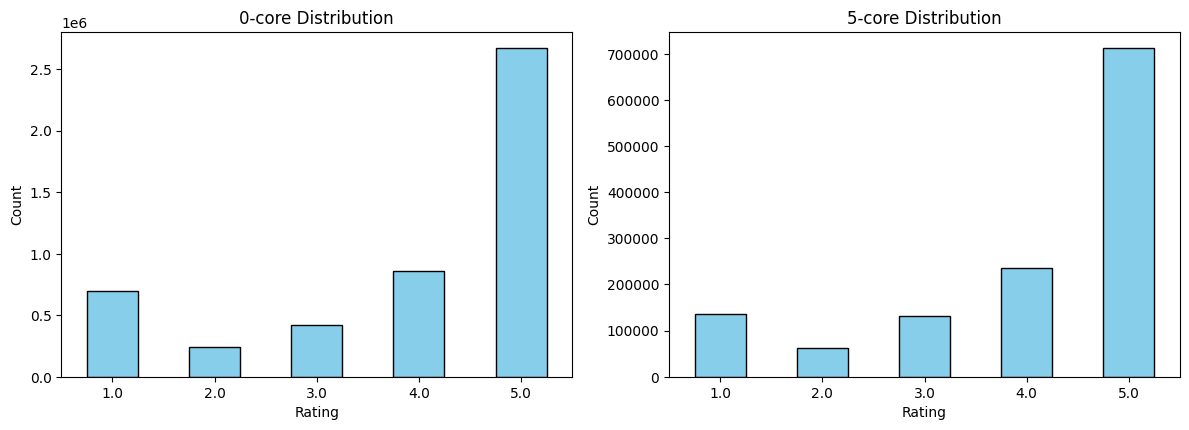

In [45]:
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

plt.subplot(2,2,1)
rating_counts = software_reviews['rating'].value_counts().sort_index()
rating_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('0-core Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.subplot(2,2,2)
five_rating_counts = five_core['rating'].value_counts().sort_index()
five_rating_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('5-core Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Keeping the 0 values, as they indicate things users did not like. The algorithms we will be using are able to train without needing to define values for the items users have never been shown, so we don't need to worry about differentiating "true" 0s from filler values. This allows the model to get information from negative signal which should aid us in generating quality recommendations.

In [46]:
user_rating_counts = five_core['user_id'].value_counts()
item_rating_counts = five_core['parent_asin'].value_counts()

combined_stats = pd.DataFrame({
    'Ratings per User': user_rating_counts.describe(),
    'Ratings per Item': item_rating_counts.describe()
}).round(2)

display(combined_stats)

int(user_rating_counts.quantile(0.95))

,Ratings per User,Ratings per Item
count,146396.00,17591.00
mean,8.72,72.58
std,7.18,317.99
min,5.00,5.00
25%,5.00,7.00
50%,7.00,13.00
75%,9.00,36.00
max,296.00,12715.00


20

We will additionally be converting the ratings from explicit values to implicit binary values indicating whether a given user liked an item. The threshold will be a 4 or higher converting to a 1 and a 3 or lower to a 0. This benefits us in a number of ways. If using the full range of values, models would value predicting a 1 as highly as a 5. Given we only care about identifying items a user might like, converting ratings to a binary classification allows us to choose metrics which optimize for identifying liked items instead of attempting to identify just how much a user would dislike an item. In this vein, binary classification has a large number of metrics we can use to asses the quality of the recommendations we provide, which we will make extensive use of. Lastly, converting to binary values provides us with valuable negative cases which we can train our models on, indicating not just interacted and uninteracted items but items which were interacted with and actively disliked.

In [47]:
# Convert dataset to implicit ratings depending on whether we are using the five core or zero core
implicit_data = pd.DataFrame
if config['five_core']:
    five_core['implicit_rating'] = (five_core['rating'] >= 4).astype(int)
    implicit_data = five_core.copy().drop(['rating', 'timestamp'], axis=1)
else:
    software_reviews['implicit_rating'] = (software_reviews['rating'] >= 4).astype(int)
    implicit_data = software_reviews.copy().drop('rating', axis=1)

Looking at some quick statistics, we can see that a full quarter of all reviews are negative, and two thirds of users have at least one negative review. While some prolific negative reviewers are pulling the average number of negatives up, a significant portion of the population has both positive and negative ratings which could allow our models to better differentiate and increase the liklihood of good recommendations if included in training.

In [48]:
neg_df = implicit_data[implicit_data['implicit_rating'] == 0]
user_neg_counts = neg_df.groupby('user_id').size()
print(f"Percent of reviews that are negative: {round(len(neg_df) / len(five_core) * 100, 2)}")
print(f"Percent of users with explicit negatives: {round(len(user_neg_counts)/implicit_data['user_id'].nunique(), 3) * 100}")
print(f"Average explicit negatives per user: {user_neg_counts.mean():.1f}")
print(f"Percent of users with 3+ explicit negatives: {round((user_neg_counts >= 3).sum()/implicit_data['user_id'].nunique(), 3) * 100}")

Percent of reviews that are negative: 25.84
Percent of users with explicit negatives: 66.9
Average explicit negatives per user: 3.4
Percent of users with 3+ explicit negatives: 30.0


# Training Preparation

Due to the highly sparse nature of our dataset we will be splitting our data into train, test, and validation sets instead of the traditional train/test split used for most other models. After each training epoch, the model will be tested on the validation set to determine whether it is truly improving. This helps prevent the tendency of recommenders to overfit the training data while still preserving the test set for final model evaluation. We will be using a 70/20/10 train/validate/test split for our data.

In [49]:
# Set up encodings for continuous indices (revisit for efficiency if needed, probably not where resource constraints will hit though)
user_encoder = LabelEncoder()
item_encoder = LabelEncoder()

# Don't modify og
encode_tmp = implicit_data.copy()
encode_tmp['user_idx'] = user_encoder.fit_transform(encode_tmp['user_id'])
encode_tmp['item_idx'] = item_encoder.fit_transform(encode_tmp['parent_asin'])

# For later reference
config.update({
    'user_encoder': user_encoder,
    'item_encoder': item_encoder,
    'n_users': len(user_encoder.classes_),
    'n_items': len(item_encoder.classes_)
})

encoded_data = encode_tmp[['user_idx', 'item_idx', 'implicit_rating']]

# Split data, using train/validate/test split
train_df, temp_df = train_test_split(
    encoded_data,
    test_size=1-config['train_split'],
    random_state=config['random_state'],
    stratify=encoded_data['implicit_rating']
)

# Avoid hardcoding things as I tinker
val_size = config['val_split'] / (config['val_split'] + config['test_split'])
val_df, test_df = train_test_split(
    temp_df,
    test_size=1-val_size,
    random_state=config['random_state'],
    stratify=temp_df['implicit_rating']
)

The choice of loss function when training a model is crucial, and for this project we will be using Bayesian Personalized Ranking loss (BPR) when training. While there are multiple ways to calculate BPR loss, we will be using the traditional sigmoid method as it pairs nicely with the tendency to use sigmoid as the output function for neural networks. BPR is a method that attempts to address the difficulty of training recommenders with implicit data by ranking items for a user. The assumption is that if a user interacted with an item they liked it, and it should be rated higher than uninteracted items. By optimizing BPR we are maximizing the liklihood that we are able to identify items a user liked without focussing on identifying items they did not. The conversion of our ratings to binary values means we also have explicit negative feedback to help create this stratification, and we will impliment a sampling strategy which allows us to explicitly include negative ratings more frequently in order to evaluate their impact.

In addition to BPR, we will also be monitoring Binary Cross-Entropy (BCE) during validation and testing. BCE is a loss function more geared towards binary classification than recommendations and measures the difference between predicted probabilities and the actual binary label. It quantifies confidence and correctness, with low values when confidence is high but predictions are wrong with exponentially larger penalties for confident wrong answers than uncertain ones. While not directly used in training or model selection, it is present as an interpretable loss metric which indicates model convergence. It served as a very useful tool during development and debugging and remains in the project as a result.

For actual model evaluation and selection we are using Normalized Discounted Cumulative Gain at 10 (NDCG@10). NDCG is a measure of how well a model orders items by comparing predicted and actual rankings and factors in relevance, meaning correctly predicting items ranked higher has more of an impact. The full calculation sums relevance scores and applies a logarithmic penalty based on item position, then normalizes by dividing by the ideal discounted cumulative gain to get a value between 0 and 1. Setting a cutoff at 10 means we are only evaluating the top 10 recomended values against the top 10 ideal values to better reflect real world conditions as few people consider anything beyond the first few recommendations.

In [50]:
class BPRLoss(nn.Module):
    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin

    def forward(self, pos_scores, neg_scores):
        if neg_scores.dim() > 1:
            # Multiple negative samples per positive for BPR
            pos_scores = pos_scores.unsqueeze(1)
            diff = pos_scores - neg_scores
            loss = -torch.log(torch.sigmoid(diff) + 1e-8).mean()
        else:
            # Leftover from when BCE was in this but things break if it is removed
            diff = pos_scores - neg_scores
            loss = -torch.log(torch.sigmoid(diff) + 1e-8).mean()

        return loss

A lot of examples and tutorials make it seem like you should convert to tensors in __get_item__ only, but pre-batching tensors dropped training times from over 30 minutes per model to 2 minutes at the cost of a few extra seconds during initialization, well worth the cost.

### Pytorch and Lightning

Lightning is an extension of PyTorch that seeks to formalize training PyTorch models by creating a clean separation of concerns to better organize modeling and create more reproducible and modular projects. The three major components are Datasets, Data Modules, and Models (or Modules) which each handle distinct aspects of the training process. We will start with the Dataset defined below. Datasets are responsible for directly interacting with the raw data, including performing preprocessing and fetching of samples. In this project the training, validation, and testing dataframes are all converted to the same kind of dataset, but it is also possible to impliment different datasets for each if needed. In this dataset we have logic for balancing user samples to prevent prolific reviewers from dominating training as well as logic for explicit negative sampling. It is important to note that we convert the items to tensors when the datasets are created at the beginning of training, not when __get_item__() is called as in many examples. This got rid of a major bottleneck in training which decreased model training times by 90% at the cost of a few extra seconds during model setup.

In [51]:
class ProductionFastDataset(Dataset):
    def __init__(self, df, num_items, batch_size=8192, use_bpr=True, neg_ratio=2,
                 balance_users=True, max_samples_per_user=14, explicit_neg_ratio=1.0):
        self.batch_size = batch_size
        self.use_bpr = use_bpr
        self.neg_ratio = neg_ratio
        self.explicit_neg_ratio = explicit_neg_ratio
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        # Apply user balancing if requested
        if balance_users:
            print(f"Balancing users (max {max_samples_per_user} samples per user)...")
            df = self._balance_user_samples(df, max_samples_per_user)
            print(f"After balancing: {len(df)} samples")

        if use_bpr:
            # Filter positive samples
            pos_df = df[df['implicit_rating'] == 1].reset_index(drop=True)

            # Build user explicit negatives mapping for sampling
            self.user_explicit_negs = self._build_explicit_negatives_map(df)

            # Convert to tensors on CPU first
            user_ids = torch.tensor(pos_df['user_idx'].values, dtype=torch.long)
            pos_items = torch.tensor(pos_df['item_idx'].values, dtype=torch.long)

            neg_items = self._generate_smart_negatives(pos_df, num_items, neg_ratio, explicit_neg_ratio)

            # Pre-batch everything
            self.batches = []
            num_samples = len(pos_df)
            num_batches = (num_samples + batch_size - 1) // batch_size

            for i in range(num_batches):
                start_idx = i * batch_size
                end_idx = min((i + 1) * batch_size, num_samples)

                batch = {
                    'user_id': user_ids[start_idx:end_idx].to(device),
                    'pos_item': pos_items[start_idx:end_idx].to(device),
                    'neg_items': neg_items[start_idx:end_idx].to(device),
                    'use_bpr': True
                }
                self.batches.append(batch)
        else:
            # BCE format
            user_ids = torch.tensor(df['user_idx'].values, dtype=torch.long)
            item_ids = torch.tensor(df['item_idx'].values, dtype=torch.long)
            ratings = torch.tensor(df['implicit_rating'].values, dtype=torch.float32)

            # Pre-batch everything
            self.batches = []
            num_samples = len(df)
            num_batches = (num_samples + batch_size - 1) // batch_size

            for i in range(num_batches):
                start_idx = i * batch_size
                end_idx = min((i + 1) * batch_size, num_samples)

                batch = {
                    'user_id': user_ids[start_idx:end_idx].to(device),
                    'item_id': item_ids[start_idx:end_idx].to(device),
                    'rating': ratings[start_idx:end_idx].to(device),
                    'use_bpr': False
                }
                self.batches.append(batch)

        print(f"Created {len(self.batches)} pre-batched GPU tensors")

    def _build_explicit_negatives_map(self, df):
        user_explicit_negs = {}
        neg_df = df[df['implicit_rating'] == 0]

        for user_id in neg_df['user_idx'].unique():
            user_negs = neg_df[neg_df['user_idx'] == user_id]['item_idx'].values
            user_explicit_negs[user_id] = set(user_negs)

        return user_explicit_negs

    def _generate_smart_negatives(self, pos_df, num_items, neg_ratio, explicit_ratio):
        num_explicit = int(neg_ratio * explicit_ratio)
        num_random = neg_ratio - num_explicit

        all_negatives = []

        for _, row in pos_df.iterrows():
            user_id = int(row['user_idx'])
            user_explicit_negs = self.user_explicit_negs.get(user_id, set())

            negatives = []

            # First, try to get explicit negatives
            if num_explicit > 0 and len(user_explicit_negs) > 0:
                available_explicit = list(user_explicit_negs)
                if len(available_explicit) >= num_explicit:
                    # Randomly sample from available explicit negatives
                    selected_explicit = np.random.choice(available_explicit, num_explicit, replace=False)
                    negatives.extend(selected_explicit)
                else:
                    # Use all explicit negatives and increase random sampling
                    negatives.extend(available_explicit)
                    num_random += (num_explicit - len(available_explicit))
            else:
                # No explicit negatives available, increase random sampling
                num_random = neg_ratio

            # Fill remaining slots with random negatives
            if num_random > 0:
                # Simple random sampling for remaining slots
                random_negs = np.random.randint(0, num_items, num_random)
                negatives.extend(random_negs)

            # Ensure we have exactly neg_ratio negatives
            negatives = negatives[:neg_ratio]
            while len(negatives) < neg_ratio:
                negatives.append(np.random.randint(0, num_items))

            all_negatives.append(negatives)

        return torch.tensor(all_negatives, dtype=torch.long)

    def _balance_user_samples(self, df, max_samples_per_user):
        balanced_dfs = []

        # Get user counts
        user_counts = df['user_idx'].value_counts()
        heavy_users = user_counts[user_counts > max_samples_per_user].index

        if len(heavy_users) > 0:
            # Split into heavy and light users
            heavy_user_df = df[df['user_idx'].isin(heavy_users)]
            light_user_df = df[~df['user_idx'].isin(heavy_users)]

            # Sample heavy users efficiently - fix the warning
            heavy_balanced = (heavy_user_df
                            .groupby('user_idx', group_keys=False)  # Add group_keys=False
                            .apply(lambda x: x.sample(n=min(len(x), max_samples_per_user),
                                                    random_state=42)))

            # Combine with light users
            return pd.concat([light_user_df, heavy_balanced], ignore_index=True)
        else:
            return df

    def __len__(self):
        return len(self.batches)

    def __getitem__(self, idx):
        return self.batches[idx]

Data Modules are responsible for orchestrating data pipeline. They create the datasets used for training, validation, and testing and define the DataLoaders which are called under the hood when datasets are needed. Often data download and splitting or preprocessing would take place in this stage, however we have already performed that as part of our data exploration in this project. Batching is often also handled by the DataLoader, but due to the sampling and balancing as well as the different data needs of BPR and BCE that logic was included in the Datasets themselves.

In [52]:
class FastDataModule(pl.LightningDataModule):
    def __init__(
        self,
        train_df,
        val_df,
        test_df=None,
        num_items=None,
        batch_size: int = 8192,
        val_batch_size: Optional[int] = None,
        balance_users: bool = True,
        max_samples_per_user: int = 14,
        neg_ratio: int = 2,
        explicit_neg_ratio: float = 1.0,
    ):
        super().__init__()
        self.train_df = train_df
        self.val_df = val_df
        self.test_df = test_df
        self.num_items = num_items or max(train_df['item_idx'].max(), val_df['item_idx'].max()) + 1
        self.batch_size = batch_size
        self.val_batch_size = val_batch_size or batch_size
        self.balance_users = balance_users
        self.max_samples_per_user = max_samples_per_user
        self.neg_ratio = neg_ratio
        self.explicit_neg_ratio = explicit_neg_ratio

    def setup(self, stage: Optional[str] = None):
        if stage == "fit" or stage is None:
            # Train using BPR with smart negative sampling
            self.train_dataset = ProductionFastDataset(
                self.train_df,
                self.num_items,
                batch_size=self.batch_size,
                use_bpr=True,
                neg_ratio=self.neg_ratio,
                balance_users=self.balance_users,
                max_samples_per_user=self.max_samples_per_user,
                explicit_neg_ratio=self.explicit_neg_ratio
            )
            # Validation using BCE without balancing
            self.val_dataset = ProductionFastDataset(
                self.val_df,
                self.num_items,
                batch_size=self.val_batch_size,
                use_bpr=False,
                balance_users=False  # Don't balance validation
            )

            print(f"Validation dataset size: {len(self.val_dataset)} batches")
            print(f"Val batch size: {self.val_batch_size}")

        if stage == "test" or stage is None:
            if self.test_df is not None:
                self.test_dataset = ProductionFastDataset(
                    self.test_df,
                    self.num_items,
                    batch_size=self.val_batch_size,
                    use_bpr=False,
                    balance_users=False  # Don't balance test
                )

    def train_dataloader(self):
        return DataLoader(
            self.train_dataset,
            batch_size=1,  # Each item is already a batch
            shuffle=True,
            num_workers=0,  # No workers needed
            collate_fn=lambda x: x[0]  # Just return the single batch
        )

    def val_dataloader(self):
        return DataLoader(
            self.val_dataset,
            batch_size=1,
            shuffle=False,
            num_workers=0,
            collate_fn=lambda x: x[0]
        )

    def test_dataloader(self):
        if self.test_df is not None:
            return DataLoader(
                self.test_dataset,
                batch_size=1,
                shuffle=False,
                num_workers=0,
                collate_fn=lambda x: x[0]
            )

Models are the last component, and by far the most complicated. For this project a base model was created that each of the individual models inherit from. This was done to ensure all models used the same training and evaluation logic and to cut down on duplicat code. When a model is initialized the loss function and evaluation metrics are defined and any hyperparameters are saved. The model contains definitions for a forward pass, training, validation, and test steps, optimizer, scheduler, and any helper functions needed. There are functions for managing the beginning and ending of epochs as well. The optimizer and schedulers are defined in the same function and handle the adjustment of embeddings and other model aspects as well as decreasing the learning rate or adjusting other parameters. For the models in this project we are using the AdamW optimizer as it is much more efficient than SGD. Additionally we are decreasing the learning rate on a fixed number of epochs to help model convergence. The base model has logic for training in batches to improve stability and chunking for the final test step to prevent massive memory spikes. It is important to note that the validation stage at the end of every epoch is only evaluating 10% of the available data on any given iteration. This is a necessary concesion to ensure timely model training, however, as we will see in the model evaluation it does not do much to damage model performance in the evaluation metrics.

In [53]:
# Shared evaluation and training logic between models
class BaseRecommenderModel(pl.LightningModule):

    def __init__(
        self,
        num_users: int,
        num_items: int,
        embedding_dim: int = 64,
        dropout_rate: float = 0.2,
        learning_rate: float = 1e-3,
        weight_decay: float = 1e-4,
        loss_type: str = 'bpr',
        eval_chunk_size: int = 10000,
        top_k: int = 10
    ):
        super().__init__()
        self.save_hyperparameters()

        # Loss functions
        self.bpr_loss = BPRLoss()
        self.bce_loss = nn.BCEWithLogitsLoss()

        # Evaluation Metrics
        self.val_ndcg = RetrievalNormalizedDCG(top_k=self.hparams.top_k)
        self.test_ndcg = RetrievalNormalizedDCG(top_k=self.hparams.top_k)
        self.val_recall = RetrievalRecall(top_k=self.hparams.top_k)
        self.test_recall = RetrievalRecall(top_k=self.hparams.top_k)
        self.val_precision = RetrievalPrecision(top_k=self.hparams.top_k)
        self.test_precision = RetrievalPrecision(top_k=self.hparams.top_k)

        # Store validation outputs for batch processing
        self.validation_outputs = []
        self.test_outputs = []

    # Forward passes are implimented by the models
    def forward(self, user_ids: torch.Tensor, item_ids: torch.Tensor) -> torch.Tensor:
        raise NotImplementedError("Subclasses must implement forward method")

    def compute_loss(self, batch: Dict[str, torch.Tensor]) -> torch.Tensor:
        # Check if this is a BPR batch by looking for the 'pos_item' key
        use_bpr = 'pos_item' in batch

        if use_bpr:
            user_ids = batch['user_id']
            pos_items = batch['pos_item']
            neg_items = batch['neg_items']

            pos_scores = self.forward(user_ids, pos_items)

            batch_size, num_neg = neg_items.shape
            user_ids_expanded = user_ids.unsqueeze(1).expand(-1, num_neg).reshape(-1)
            neg_items_flat = neg_items.reshape(-1)
            neg_scores = self.forward(user_ids_expanded, neg_items_flat)
            neg_scores = neg_scores.reshape(batch_size, num_neg)

            loss = self.bpr_loss(pos_scores, neg_scores)
        else:
            user_ids = batch['user_id']
            item_ids = batch['item_id']
            ratings = batch['rating']

            predictions = self.forward(user_ids, item_ids)
            loss = self.bce_loss(predictions, ratings)

        return loss

    def training_step(self, batch: Dict[str, torch.Tensor], batch_idx: int) -> torch.Tensor:
        loss = self.compute_loss(batch)

        # Get actual batch size for proper logging to find problem
        if 'user_id' in batch:
            actual_batch_size = batch['user_id'].size(0)
        else:
            actual_batch_size = len(batch)

        self.log('train_loss', loss, on_step=True, on_epoch=True, prog_bar=True, batch_size=actual_batch_size)
        return loss

    def test_step(self, batch: Dict[str, torch.Tensor], batch_idx: int) -> Dict[str, Union[torch.Tensor, bool]]:
      user_ids = batch['user_id']
      item_ids = batch['item_id']
      ratings = batch['rating']

      with torch.no_grad():
          predictions = self.forward(user_ids, item_ids)
          test_loss = self.bce_loss(predictions, ratings)

      self.log('test_loss', test_loss, on_step=False, on_epoch=True, prog_bar=True, batch_size=user_ids.size(0))

      return {
          'predictions': torch.sigmoid(predictions),
          'targets': ratings,
          'user_ids': user_ids,
          'is_full_eval': True
      }

    def on_test_epoch_start(self):
        # Make sure test results are clear, should be done already but to be safe
        self.test_outputs = []

    # Store batch outputs for later processing instead of immediate evaluation
    def on_test_batch_end(self, outputs, batch, batch_idx):
        if outputs is not None:
            self.test_outputs.append(outputs)

    # Calculate results at end of epoch
    def on_test_epoch_end(self):
        if not self.test_outputs:
            return

        # Concatenate all outputs
        all_predictions = torch.cat([x['predictions'] for x in self.test_outputs])
        all_targets = torch.cat([x['targets'] for x in self.test_outputs])
        all_user_ids = torch.cat([x['user_ids'] for x in self.test_outputs])

        self._compute_and_log_test_metrics(all_predictions, all_targets, all_user_ids)

        # Clear outputs to free memory
        self.test_outputs = []

    def _compute_and_log_test_metrics(self, predictions, targets, user_ids):

        chunk_size = 5000  # Smaller chunks for safety
        self.test_ndcg.reset()
        self.test_recall.reset()
        self.test_precision.reset()

        total_chunks = (len(predictions) + chunk_size - 1) // chunk_size

        for i in range(0, len(predictions), chunk_size):
            end_idx = min(i + chunk_size, len(predictions))

            chunk_preds = predictions[i:end_idx]
            chunk_targets = targets[i:end_idx]
            chunk_users = user_ids[i:end_idx]

            # Create indexes for this chunk only
            unique_users, inverse_indices = torch.unique(chunk_users, return_inverse=True)

            # Update metrics incrementally
            self.test_ndcg.update(chunk_preds, chunk_targets, indexes=inverse_indices)
            self.test_recall.update(chunk_preds, chunk_targets, indexes=inverse_indices)
            self.test_precision.update(chunk_preds, chunk_targets, indexes=inverse_indices)

            # Clear GPU cache periodically
            if (i // chunk_size) % 10 == 0:
                torch.cuda.empty_cache()

        # Compute final metrics
        ndcg = self.test_ndcg.compute()
        recall = self.test_recall.compute()
        precision = self.test_precision.compute()

        print(f"Test metrics computed: NDCG={ndcg:.4f}, Recall={recall:.4f}, Precision={precision:.4f}")

        self.log(f'test_ndcg@{self.hparams.top_k}', ndcg, prog_bar=True)
        self.log(f'test_recall@{self.hparams.top_k}', recall, prog_bar=True)
        self.log(f'test_precision@{self.hparams.top_k}', precision, prog_bar=True)


    # Pretty much the same as test step, should probably combine logic
    def validation_step(self, batch: Dict[str, torch.Tensor], batch_idx: int):
      user_ids = batch['user_id']
      item_ids = batch['item_id']
      ratings = batch['rating']

      with torch.no_grad():
          predictions = self.forward(user_ids, item_ids)
          val_loss = self.bce_loss(predictions, ratings)

      self.log('val_loss', val_loss, on_step=False, on_epoch=True, prog_bar=True, batch_size=user_ids.size(0))

      # Sample only 10% for metrics (this will cut time from 60s to 6s)
      batch_size = user_ids.size(0)
      sample_size = int(0.1 * batch_size)
      if sample_size > 0:
          indices = torch.randperm(batch_size, device=user_ids.device)[:sample_size]
          user_ids = user_ids[indices]
          predictions = predictions[indices]
          ratings = ratings[indices]

      return {
          'predictions': torch.sigmoid(predictions),
          'targets': ratings,
          'user_ids': user_ids,
          'is_full_eval': False
      }

    def on_validation_epoch_start(self):
      self.validation_outputs = []

    def on_validation_batch_end(self, outputs, batch, batch_idx):
      if outputs is not None:
          outputs_cpu = {
              'predictions': outputs['predictions'].detach().cpu(),
              'targets': outputs['targets'].detach().cpu(),
              'user_ids': outputs['user_ids'].detach().cpu(),
              'is_full_eval': outputs['is_full_eval']
          }
      self.validation_outputs.append(outputs_cpu)

    def on_validation_epoch_end(self):
      if not self.validation_outputs:
          print("No validation outputs!")
          return

      # Concatenate all outputs
      all_predictions = torch.cat([x['predictions'] for x in self.validation_outputs])
      all_targets = torch.cat([x['targets'] for x in self.validation_outputs])
      all_user_ids = torch.cat([x['user_ids'] for x in self.validation_outputs])

      # Time each metric separately
      self._compute_and_log_metrics(all_predictions, all_targets, all_user_ids)

      self.validation_outputs = []

    def _compute_and_log_metrics(self, predictions, targets, user_ids):
      chunk_size = 5000  # Same as test

      self.val_ndcg.reset()
      self.val_recall.reset()
      self.val_precision.reset()

      total_chunks = (len(predictions) + chunk_size - 1) // chunk_size

      for i in range(0, len(predictions), chunk_size):
          end_idx = min(i + chunk_size, len(predictions))

          chunk_preds = predictions[i:end_idx]
          chunk_targets = targets[i:end_idx]
          chunk_users = user_ids[i:end_idx]

          unique_users, inverse_indices = torch.unique(chunk_users, return_inverse=True)

          self.val_ndcg.update(chunk_preds, chunk_targets, indexes=inverse_indices)
          self.val_recall.update(chunk_preds, chunk_targets, indexes=inverse_indices)
          self.val_precision.update(chunk_preds, chunk_targets, indexes=inverse_indices)

          # Clear GPU cache
          if (i // chunk_size) % 10 == 0:
              torch.cuda.empty_cache()

      # Compute final metrics
      ndcg = self.val_ndcg.compute()
      recall = self.val_recall.compute()
      precision = self.val_precision.compute()

      self.log(f'val_ndcg@{self.hparams.top_k}', ndcg, prog_bar=True)
      self.log(f'val_recall@{self.hparams.top_k}', recall, prog_bar=True)
      self.log(f'val_precision@{self.hparams.top_k}', precision, prog_bar=True)

    def predict_for_user(self, user_id: int, item_ids: Optional[torch.Tensor] = None) -> torch.Tensor:
        self.eval()

        if item_ids is None:
            item_ids = torch.arange(self.hparams.num_items, device=self.device)

        user_ids = torch.full_like(item_ids, user_id)

        with torch.no_grad():
            predictions = self.forward(user_ids, item_ids)
            probabilities = torch.sigmoid(predictions)

        return probabilities

    def recommend_items(self, user_id: int, k: int = 10, exclude_seen: Optional[List[int]] = None) -> Tuple[torch.Tensor, torch.Tensor]:
        predictions = self.predict_for_user(user_id)

        if exclude_seen:
            predictions[exclude_seen] = -float('inf')

        top_scores, top_items = torch.topk(predictions, k)
        return top_items, top_scores

    # Don't think I need the other_params, didn't change much when experimenting
    def configure_optimizers(self):
        embedding_params = []
        other_params = []

        for name, param in self.named_parameters():
            if 'embedding' in name and 'weight' in name:
                embedding_params.append(param)
            else:
                other_params.append(param)

        # Apply weight decay only to embeddings
        param_groups = [
            {'params': embedding_params, 'weight_decay': self.hparams.weight_decay},
            {'params': other_params, 'weight_decay': self.hparams.weight_decay * 0.1}
        ]

        optimizer = AdamW(param_groups, lr=self.hparams.learning_rate)

        # Learning rate scheduler, should probably try something based on loss rate or something fancier
        scheduler = torch.optim.lr_scheduler.StepLR(
            optimizer,
            step_size=10,
            gamma=0.5
        )

        return {
            'optimizer': optimizer,
            'lr_scheduler': {
                'scheduler': scheduler,
                'interval': 'epoch'
            }
        }

## Model Definitions

This section consists of the model-specific definitions, all of which inherit from the base model defined above. The matrix factorization model is, as may be expected, fairly simple and straightforward.

In [54]:
class MatrixFactorization(BaseRecommenderModel):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.save_hyperparameters()

        # Embedding layers with dropout
        self.user_embedding = nn.Sequential(
            nn.Embedding(self.hparams.num_users, self.hparams.embedding_dim),
            nn.Dropout(self.hparams.dropout_rate)
        )
        self.item_embedding = nn.Sequential(
            nn.Embedding(self.hparams.num_items, self.hparams.embedding_dim),
            nn.Dropout(self.hparams.dropout_rate)
        )

        # Initialize embeddings, maybe try something fancier if training is long
        nn.init.normal_(self.user_embedding[0].weight, std=0.1)
        nn.init.normal_(self.item_embedding[0].weight, std=0.1)

    def forward(self, user_ids: torch.Tensor, item_ids: torch.Tensor) -> torch.Tensor:
        user_emb = self.user_embedding(user_ids)
        item_emb = self.item_embedding(item_ids)

        prediction = (user_emb * item_emb).sum(dim=-1)

        return prediction

The NCF model definition sets up the embeddings for both the matrix factorization and neural network portions of the model, as well as constructing the network architecture and defining the forward passes through the model. To provide context on the construction of the parallel neural network, the default mlp_dims value would construct a 3 layer network with the first consisting of 128 neurons, the second 64, and the third 32. The neural network is a Multi-Layer Perceptron, meaning all layers are fully connected so no additional logic is needed to manage connections. Experimenting with different network sizes, types, and activation functions would be an interesting project, but goes beyond the resource capabilities available for this project.

In [55]:
class NCFModel(BaseRecommenderModel):
    def __init__(self, gmf_dim=64, mlp_dims=[128, 64, 32], **kwargs):
        super().__init__(**kwargs)

        self.save_hyperparameters()

        # GMF embeddings
        self.gmf_user_embedding = nn.Sequential(
            nn.Embedding(self.hparams.num_users, self.hparams.gmf_dim),
            nn.Dropout(self.hparams.dropout_rate)
        )
        self.gmf_item_embedding = nn.Sequential(
            nn.Embedding(self.hparams.num_items, self.hparams.gmf_dim),
            nn.Dropout(self.hparams.dropout_rate)
        )

        # MLP embeddings
        mlp_user_dim = self.hparams.embedding_dim
        mlp_item_dim = self.hparams.embedding_dim
        self.mlp_user_embedding = nn.Sequential(
            nn.Embedding(self.hparams.num_users, mlp_user_dim),
            nn.Dropout(self.hparams.dropout_rate)
        )
        self.mlp_item_embedding = nn.Sequential(
            nn.Embedding(self.hparams.num_items, mlp_item_dim),
            nn.Dropout(self.hparams.dropout_rate)
        )

        # MLP layers
        mlp_input_dim = mlp_user_dim + mlp_item_dim
        mlp_layers = []
        input_dim = mlp_input_dim

        for hidden_dim in self.hparams.mlp_dims:
            mlp_layers.append(nn.Linear(input_dim, hidden_dim))
            mlp_layers.append(nn.ReLU()) # Maybe use something fancier? Not huge network so probably not needed
            mlp_layers.append(nn.Dropout(self.hparams.dropout_rate))
            input_dim = hidden_dim

        self.mlp = nn.Sequential(*mlp_layers)

        # Final prediction layer
        final_input_dim = gmf_dim + mlp_dims[-1]
        self.prediction = nn.Linear(final_input_dim, 1)

        # Initialize embeddings
        self._init_weights()

    def _init_weights(self):
        nn.init.normal_(self.gmf_user_embedding[0].weight, std=0.1)
        nn.init.normal_(self.gmf_item_embedding[0].weight, std=0.1)
        nn.init.normal_(self.mlp_user_embedding[0].weight, std=0.1)
        nn.init.normal_(self.mlp_item_embedding[0].weight, std=0.1)

        # Initialize MLP layers, use xavier_uniform as it can improve convergence
        for layer in self.mlp:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

        # Initialize prediction layer
        nn.init.xavier_uniform_(self.prediction.weight)
        nn.init.zeros_(self.prediction.bias)

    def forward(self, user_ids: torch.Tensor, item_ids: torch.Tensor) -> torch.Tensor:
        # GMF part
        gmf_user_emb = self.gmf_user_embedding(user_ids)
        gmf_item_emb = self.gmf_item_embedding(item_ids)
        gmf_output = gmf_user_emb * gmf_item_emb  # Element-wise product

        # MLP part
        mlp_user_emb = self.mlp_user_embedding(user_ids)
        mlp_item_emb = self.mlp_item_embedding(item_ids)
        mlp_input = torch.cat([mlp_user_emb, mlp_item_emb], dim=-1)
        mlp_output = self.mlp(mlp_input)

        # Concatenate GMF and MLP outputs
        final_input = torch.cat([gmf_output, mlp_output], dim=-1)
        prediction = self.prediction(final_input).squeeze(-1)

        return prediction



The Two Tower model is defined similarly to the previous two models. It should be noted logic to include temperature scaling is present, however we do not make use of it as extensive hyperparameter tuning and experimentation was time prohibitive.

In [56]:
class TwoTowerModel(BaseRecommenderModel):
    def __init__(self, tower_dims=[128, 64, 32], temperature=1.0, **kwargs):
        super().__init__(**kwargs)
        self.save_hyperparameters()

        # User tower
        self.user_embedding = nn.Sequential(
            nn.Embedding(self.hparams.num_users, self.hparams.embedding_dim),
            nn.Dropout(self.hparams.dropout_rate)
        )

        user_tower_layers = []
        input_dim = self.hparams.embedding_dim

        for hidden_dim in self.hparams.tower_dims:
            user_tower_layers.append(nn.Linear(input_dim, hidden_dim))
            user_tower_layers.append(nn.ReLU())
            user_tower_layers.append(nn.Dropout(self.hparams.dropout_rate))
            input_dim = hidden_dim

        # Final user representation, normalize embeddings
        user_tower_layers.append(nn.Linear(input_dim, self.hparams.embedding_dim))
        user_tower_layers.append(nn.LayerNorm(self.hparams.embedding_dim))

        self.user_tower = nn.Sequential(*user_tower_layers)

        # Item tower
        self.item_embedding = nn.Sequential(
            nn.Embedding(self.hparams.num_items, self.hparams.embedding_dim),
            nn.Dropout(self.hparams.dropout_rate)
        )

        item_tower_layers = []
        input_dim = self.hparams.embedding_dim

        for hidden_dim in self.hparams.tower_dims:
            item_tower_layers.append(nn.Linear(input_dim, hidden_dim))
            item_tower_layers.append(nn.ReLU())
            item_tower_layers.append(nn.Dropout(self.hparams.dropout_rate))
            input_dim = hidden_dim

        # Final item representation, normalize embeddings
        item_tower_layers.append(nn.Linear(input_dim, self.hparams.embedding_dim))
        item_tower_layers.append(nn.LayerNorm(self.hparams.embedding_dim))

        self.item_tower = nn.Sequential(*item_tower_layers)

        # Initialize weights
        self._init_weights()

    def _init_weights(self):
        nn.init.normal_(self.user_embedding[0].weight, std=0.1)
        nn.init.normal_(self.item_embedding[0].weight, std=0.1)

        # Initialize tower layers
        for tower in [self.user_tower, self.item_tower]:
            for layer in tower:
                if isinstance(layer, nn.Linear):
                    nn.init.xavier_uniform_(layer.weight)
                    if layer.bias is not None:
                        nn.init.zeros_(layer.bias)

    def forward(self, user_ids: torch.Tensor, item_ids: torch.Tensor) -> torch.Tensor:
        # Get user representations
        user_emb = self.user_embedding(user_ids)
        user_repr = self.user_tower(user_emb)

        # Get item representations
        item_emb = self.item_embedding(item_ids)
        item_repr = self.item_tower(item_emb)

        # Values already normalized
        prediction = (user_repr * item_repr).sum(dim=-1) / self.hparams.temperature

        return prediction

    def get_user_embeddings(self, user_ids: torch.Tensor) -> torch.Tensor:
        with torch.no_grad():
            user_emb = self.user_embedding(user_ids)
            return self.user_tower(user_emb)

    def get_item_embeddings(self, item_ids: torch.Tensor) -> torch.Tensor:
        with torch.no_grad():
            item_emb = self.item_embedding(item_ids)
            return self.item_tower(item_emb)


## Model Training

When outlining the components of the modeling process using PyTorch Lightning, a key component was omitted. That component is the trainer, which is what actually runs the whole model training process. It connects the other three components together and handles early stopping, checkpointing, logging, and a number of other possible actions. The trainer is passed the model definition and the data module to be used for training and stores the "trained" version of the model. The below function sets up an experiment and trains a given model.

In [57]:
def train_with_hyperparams(model_class, model_kwargs, data_module, model_name, dirpath, device_type = 'auto'):
    eval_chunk_size = 5000
    embedding_dim = 64
    learning_rate = 1e-3
    precision = '32'

    if device_type == 'auto':
        if torch.cuda.is_available():
            device_type = 'gpu'
            print("CUDA GPU detected - using GPU optimizations")
            eval_chunk_size = 15000
            embedding_dim = 128
            learning_rate = 2e-3
            precision = '16-mixed'
        elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
            device_type = 'mps'
            print("MPS (Laptop) detected - using MPS optimizations")
            eval_chunk_size = 10000
        else:
            device_type = 'cpu'
            print("Using CPU")

    base_args = {
        'num_users': config['n_users'],
        'num_items': config['n_items'],
        'embedding_dim': embedding_dim,
        'dropout_rate': 0.2,
        'learning_rate': learning_rate,
        'weight_decay': 1e-4,
        'eval_chunk_size': eval_chunk_size,
        'top_k': 10
    }

    model_kwargs.update(base_args)

    # Create model - hyperparameters are automatically saved!
    model = model_class(**model_kwargs)

    # Setup callbacks
    checkpoint_callback = ModelCheckpoint(
        dirpath=dirpath + '/checkpoints',
        filename=f'{model_name}_best',
        monitor='val_ndcg@10',
        mode='max',
        save_top_k=1,
        save_last=False,
        verbose=True
    )

    early_stop = EarlyStopping(
        monitor='val_ndcg@10',
        patience=10,
        min_delta=0.003, # Lots of random tiny improvements prolong training to overfit model, make sure they are meaningful
        mode='max',
        verbose=True,
        strict=False # Don't crash if metric is missing early on
    )

    # CSV logger for metrics
    csv_logger = CSVLogger(save_dir = dirpath + '/logs', name=model_name)

    trainer = pl.Trainer(
        max_epochs=100,
        precision=precision,
        gradient_clip_val=1.0,
        check_val_every_n_epoch=1,
        enable_progress_bar=True,
        enable_model_summary=True,
        callbacks=[checkpoint_callback, early_stop, DeviceStatsMonitor(cpu_stats=True)],
        logger=csv_logger,
        accelerator='gpu',
        devices=1,
        strategy='auto'
    )

    # Train
    trainer.fit(model, data_module)
    # Test
    test_results = trainer.test(model, data_module, ckpt_path="best")

    print(f"Model saved with hyperparameters to: {checkpoint_callback.best_model_path}")
    return trainer, test_results

This function makes model loading easier so that models trained with the larger parameters used by Colab can be imported locally. This allowed aspects of this notebook such as results analysis to be iterated and developed without wasting expensive cloud resources.

In [58]:
def load_and_inspect_model(checkpoint_path):
    # Load checkpoint
    checkpoint = torch.load(checkpoint_path, map_location='cpu')

    # Look for specific parameters to determine model type
    if 'gmf_dim' in checkpoint['hyper_parameters']:
        model = NCFModel.load_from_checkpoint(checkpoint_path)
    elif 'tower_dims' in checkpoint['hyper_parameters']:
        model = TwoTowerModel.load_from_checkpoint(checkpoint_path)
    else:
        model = MatrixFactorization.load_from_checkpoint(checkpoint_path)

    # Set model to evaluation mode
    model.eval()

    return model

In addition to comparing the performance of the three model types defined above, we will also be conducting a small experiment on the impact of explicit negative sampling on the performance of our models. The models will be trained on three different splits based on the distribution of negative reviews discussed in the EDA portion of this project. The first will use only explicit negative samples when available, the second will use majority explicit negatives where available, and the last will use random sampling of non-positively rated items. The ratio of positive to negative samples is adjusted for each dataset as a necessity for training.

In [59]:
fast_data_module = FastDataModule(
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    num_items=config['n_items'],
    neg_ratio=2,  # Conservative since you have limited explicit negs
    explicit_neg_ratio=1.0,  # Use 100% explicit when available
    batch_size=8192
)

fast_data_module_mixed = FastDataModule(
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    num_items=config['n_items'],
    neg_ratio=3,  # More negatives total
    explicit_neg_ratio=0.67,  # ~2 explicit + 1 random per positive
    batch_size=8192
)

fast_data_module_random = FastDataModule(
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    num_items=config['n_items'],
    neg_ratio=4,
    explicit_neg_ratio=0.0,  # No explicit negatives
    batch_size=8192
)

In [60]:
mf_model, mf_results = train_with_hyperparams(MatrixFactorization, model_kwargs={}, data_module=fast_data_module, model_name='MatrixFactorization', dirpath=config['data_path'])

MPS (Laptop) detected - using MPS optimizations


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Balancing users (max 14 samples per user)...


/var/folders/m9/g63t6db10t1byfz1txs0l4t00000gn/T/ipykernel_16063/4062102351.py:137: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), max_samples_per_user),


After balancing: 831659 samples
Created 76 pre-batched GPU tensors
Created 32 pre-batched GPU tensors
Validation dataset size: 32 batches
Val batch size: 8192


...

Epoch 35: 100%|██████████| 76/76 [00:02<00:00, 29.96it/s, v_num=23, train_loss_step=0.129, val_loss=0.678, val_ndcg@10=0.908, val_recall@10=0.998, val_precision@10=0.385, train_loss_epoch=0.138]

Monitored metric val_ndcg@10 did not improve in the last 10 records. Best score: 0.910. Signaling Trainer to stop.
Epoch 35, global step 2736: 'val_ndcg@10' was not in top 1


Epoch 35: 100%|██████████| 76/76 [00:02<00:00, 29.94it/s, v_num=23, train_loss_step=0.129, val_loss=0.678, val_ndcg@10=0.908, val_recall@10=0.998, val_precision@10=0.385, train_loss_epoch=0.138]

Restoring states from the checkpoint path at /Users/matttillman/School/data_612/assignments/Final/data/checkpoints/MatrixFactorization_best-v19.ckpt
Loaded model weights from the checkpoint at /Users/matttillman/School/data_612/assignments/Final/data/checkpoints/MatrixFactorization_best-v19.ckpt
/Users/matttillman/anaconda3/envs/pyspark/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.



Created 16 pre-batched GPU tensors
Testing DataLoader 0: 100%|██████████| 16/16 [00:39<00:00,  0.41it/s] 
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss           0.6780045628547668
      test_ndcg@10          0.8140311241149902
    test_precision@10        0.794925332069397
     test_recall@10         0.41290250420570374
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Model saved with hyperparameters to: /Users/matttillman/School/data_612/assignments/Final/data/checkpoints/MatrixFactorization_best-v19.ckpt


In [61]:
mf_model_mixed, mf_results_mixed = train_with_hyperparams(MatrixFactorization, model_kwargs={}, data_module=fast_data_module_mixed, model_name='MatrixFactorization_mixed', dirpath=config['data_path'])

MPS (Laptop) detected - using MPS optimizations


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Balancing users (max 14 samples per user)...


/var/folders/m9/g63t6db10t1byfz1txs0l4t00000gn/T/ipykernel_16063/4062102351.py:137: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), max_samples_per_user),


After balancing: 831659 samples


...

Epoch 39: 100%|██████████| 76/76 [00:02<00:00, 28.96it/s, v_num=4, train_loss_step=0.134, val_loss=0.648, val_ndcg@10=0.912, val_recall@10=0.998, val_precision@10=0.387, train_loss_epoch=0.145]

Monitored metric val_ndcg@10 did not improve in the last 10 records. Best score: 0.915. Signaling Trainer to stop.
Epoch 39, global step 3040: 'val_ndcg@10' was not in top 1


Epoch 39: 100%|██████████| 76/76 [00:02<00:00, 28.94it/s, v_num=4, train_loss_step=0.134, val_loss=0.648, val_ndcg@10=0.912, val_recall@10=0.998, val_precision@10=0.387, train_loss_epoch=0.145]

Restoring states from the checkpoint path at /Users/matttillman/School/data_612/assignments/Final/data/checkpoints/MatrixFactorization_mixed_best-v4.ckpt
Loaded model weights from the checkpoint at /Users/matttillman/School/data_612/assignments/Final/data/checkpoints/MatrixFactorization_mixed_best-v4.ckpt
/Users/matttillman/anaconda3/envs/pyspark/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.



Created 16 pre-batched GPU tensors
Testing DataLoader 0: 100%|██████████| 16/16 [00:34<00:00,  0.47it/s] 
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss           0.6514515280723572
      test_ndcg@10          0.8263000845909119
    test_precision@10       0.8084919452667236
     test_recall@10         0.4203800559043884
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Model saved with hyperparameters to: /Users/matttillman/School/data_612/assignments/Final/data/checkpoints/MatrixFactorization_mixed_best-v4.ckpt


In [62]:
mf_model_random, mf_results_random = train_with_hyperparams(MatrixFactorization, model_kwargs={}, data_module=fast_data_module_random, model_name='MatrixFactorization_random', dirpath=config['data_path'])

MPS (Laptop) detected - using MPS optimizations


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Balancing users (max 14 samples per user)...


/var/folders/m9/g63t6db10t1byfz1txs0l4t00000gn/T/ipykernel_16063/4062102351.py:137: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), max_samples_per_user),


After balancing: 831659 samples


...

Epoch 33: 100%|██████████| 76/76 [00:02<00:00, 26.54it/s, v_num=4, train_loss_step=0.131, val_loss=0.593, val_ndcg@10=0.922, val_recall@10=0.999, val_precision@10=0.387, train_loss_epoch=0.141]

Restoring states from the checkpoint path at /Users/matttillman/School/data_612/assignments/Final/data/checkpoints/MatrixFactorization_random_best-v4.ckpt



Created 16 pre-batched GPU tensors


Loaded model weights from the checkpoint at /Users/matttillman/School/data_612/assignments/Final/data/checkpoints/MatrixFactorization_random_best-v4.ckpt
/Users/matttillman/anaconda3/envs/pyspark/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Testing DataLoader 0: 100%|██████████| 16/16 [00:32<00:00,  0.49it/s] 
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss           0.5948442816734314
      test_ndcg@10          0.8335656523704529
    test_precision@10       0.8216493129730225
     test_recall@10         0.4274786710739136
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Model saved with hyperparameters to: /Users/matttillman/School/data_612/assignments/Final/data/checkpoints/MatrixFactorization_random_best-v4.ckpt


In [63]:
ncf_model, ncf_results = train_with_hyperparams(NCFModel, model_kwargs={}, data_module=fast_data_module, model_name='NCF', dirpath=config['data_path'])


MPS (Laptop) detected - using MPS optimizations


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Balancing users (max 14 samples per user)...


/var/folders/m9/g63t6db10t1byfz1txs0l4t00000gn/T/ipykernel_16063/4062102351.py:137: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), max_samples_per_user),


After balancing: 831659 samples


...

Epoch 12: 100%|██████████| 76/76 [00:04<00:00, 15.87it/s, v_num=14, train_loss_step=0.0417, val_loss=0.819, val_ndcg@10=0.927, val_recall@10=0.999, val_precision@10=0.389, train_loss_epoch=0.0496]

Restoring states from the checkpoint path at /Users/matttillman/School/data_612/assignments/Final/data/checkpoints/NCF_best-v15.ckpt



Created 16 pre-batched GPU tensors


Loaded model weights from the checkpoint at /Users/matttillman/School/data_612/assignments/Final/data/checkpoints/NCF_best-v15.ckpt
/Users/matttillman/anaconda3/envs/pyspark/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Testing DataLoader 0: 100%|██████████| 16/16 [00:33<00:00,  0.48it/s] 
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss           0.6762567758560181
      test_ndcg@10          0.8698992133140564
    test_precision@10       0.8511356711387634
     test_recall@10         0.4433385133743286
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Model saved with hyperparameters to: /Users/matttillman/School/data_612/assignments/Final/data/checkpoints/NCF_best-v15.ckpt


In [64]:
ncf_model_mixed, ncf_results_mixed = train_with_hyperparams(NCFModel, model_kwargs={}, data_module=fast_data_module_mixed, model_name='NCF_mixed', dirpath=config['data_path'])

MPS (Laptop) detected - using MPS optimizations


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Balancing users (max 14 samples per user)...


/var/folders/m9/g63t6db10t1byfz1txs0l4t00000gn/T/ipykernel_16063/4062102351.py:137: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), max_samples_per_user),


After balancing: 831659 samples


...

Epoch 11: 100%|██████████| 76/76 [00:05<00:00, 14.29it/s, v_num=4, train_loss_step=0.054, val_loss=0.810, val_ndcg@10=0.924, val_recall@10=0.998, val_precision@10=0.388, train_loss_epoch=0.0661]

Restoring states from the checkpoint path at /Users/matttillman/School/data_612/assignments/Final/data/checkpoints/NCF_mixed_best-v4.ckpt



Created 16 pre-batched GPU tensors


Loaded model weights from the checkpoint at /Users/matttillman/School/data_612/assignments/Final/data/checkpoints/NCF_mixed_best-v4.ckpt
/Users/matttillman/anaconda3/envs/pyspark/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Testing DataLoader 0: 100%|██████████| 16/16 [00:33<00:00,  0.48it/s] 
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss           0.7005985975265503
      test_ndcg@10          0.8618406057357788
    test_precision@10       0.8434009552001953
     test_recall@10         0.43917417526245117
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Model saved with hyperparameters to: /Users/matttillman/School/data_612/assignments/Final/data/checkpoints/NCF_mixed_best-v4.ckpt


In [65]:
ncf_model_random, ncf_results_random = train_with_hyperparams(NCFModel, model_kwargs={}, data_module=fast_data_module_random, model_name='NCF_random', dirpath=config['data_path'])

MPS (Laptop) detected - using MPS optimizations


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Balancing users (max 14 samples per user)...


/var/folders/m9/g63t6db10t1byfz1txs0l4t00000gn/T/ipykernel_16063/4062102351.py:137: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), max_samples_per_user),


After balancing: 831659 samples


...

Epoch 14: 100%|██████████| 76/76 [00:12<00:00,  6.22it/s, v_num=4, train_loss_step=0.0553, val_loss=1.020, val_ndcg@10=0.916, val_recall@10=0.998, val_precision@10=0.389, train_loss_epoch=0.0474]

Monitored metric val_ndcg@10 did not improve in the last 10 records. Best score: 0.913. Signaling Trainer to stop.
Epoch 14, global step 1140: 'val_ndcg@10' reached 0.91584 (best 0.91584), saving model to '/Users/matttillman/School/data_612/assignments/Final/data/checkpoints/NCF_random_best-v4.ckpt' as top 1


Epoch 14: 100%|██████████| 76/76 [00:12<00:00,  6.00it/s, v_num=4, train_loss_step=0.0553, val_loss=1.020, val_ndcg@10=0.916, val_recall@10=0.998, val_precision@10=0.389, train_loss_epoch=0.0474]

Restoring states from the checkpoint path at /Users/matttillman/School/data_612/assignments/Final/data/checkpoints/NCF_random_best-v4.ckpt
Loaded model weights from the checkpoint at /Users/matttillman/School/data_612/assignments/Final/data/checkpoints/NCF_random_best-v4.ckpt
/Users/matttillman/anaconda3/envs/pyspark/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.



Created 16 pre-batched GPU tensors
Testing DataLoader 0: 100%|██████████| 16/16 [00:33<00:00,  0.48it/s] 
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss           1.0243252515792847
      test_ndcg@10          0.8068631291389465
    test_precision@10       0.7970739006996155
     test_recall@10         0.41444870829582214
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Model saved with hyperparameters to: /Users/matttillman/School/data_612/assignments/Final/data/checkpoints/NCF_random_best-v4.ckpt


In [66]:
tt_model, tt_results = train_with_hyperparams(TwoTowerModel, model_kwargs={}, data_module=fast_data_module, model_name='Two Tower', dirpath=config['data_path'])


MPS (Laptop) detected - using MPS optimizations


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Balancing users (max 14 samples per user)...


/var/folders/m9/g63t6db10t1byfz1txs0l4t00000gn/T/ipykernel_16063/4062102351.py:137: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), max_samples_per_user),


After balancing: 831659 samples


...

Epoch 15: 100%|██████████| 76/76 [00:05<00:00, 13.46it/s, v_num=14, train_loss_step=0.296, val_loss=0.920, val_ndcg@10=0.928, val_recall@10=0.998, val_precision@10=0.387, train_loss_epoch=0.307]

Restoring states from the checkpoint path at /Users/matttillman/School/data_612/assignments/Final/data/checkpoints/Two Tower_best-v16.ckpt



Created 16 pre-batched GPU tensors


Loaded model weights from the checkpoint at /Users/matttillman/School/data_612/assignments/Final/data/checkpoints/Two Tower_best-v16.ckpt
/Users/matttillman/anaconda3/envs/pyspark/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Testing DataLoader 0: 100%|██████████| 16/16 [00:33<00:00,  0.47it/s] 
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss           0.9061951637268066
      test_ndcg@10          0.8638957738876343
    test_precision@10       0.8468794226646423
     test_recall@10         0.44091758131980896
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Model saved with hyperparameters to: /Users/matttillman/School/data_612/assignments/Final/data/checkpoints/Two Tower_best-v16.ckpt


In [67]:
tt_model_mixed, tt_results_mixed = train_with_hyperparams(TwoTowerModel, model_kwargs={}, data_module=fast_data_module_mixed, model_name='Two Tower_mixed', dirpath=config['data_path'])

MPS (Laptop) detected - using MPS optimizations


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Balancing users (max 14 samples per user)...


/var/folders/m9/g63t6db10t1byfz1txs0l4t00000gn/T/ipykernel_16063/4062102351.py:137: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), max_samples_per_user),


After balancing: 831659 samples


...

Epoch 19: 100%|██████████| 76/76 [00:05<00:00, 13.04it/s, v_num=4, train_loss_step=0.273, val_loss=1.070, val_ndcg@10=0.929, val_recall@10=0.999, val_precision@10=0.388, train_loss_epoch=0.283]

Restoring states from the checkpoint path at /Users/matttillman/School/data_612/assignments/Final/data/checkpoints/Two Tower_mixed_best-v4.ckpt



Created 16 pre-batched GPU tensors


Loaded model weights from the checkpoint at /Users/matttillman/School/data_612/assignments/Final/data/checkpoints/Two Tower_mixed_best-v4.ckpt
/Users/matttillman/anaconda3/envs/pyspark/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Testing DataLoader 0: 100%|██████████| 16/16 [00:34<00:00,  0.46it/s] 
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss           1.0203561782836914
      test_ndcg@10          0.8582690954208374
    test_precision@10        0.840924859046936
     test_recall@10         0.43770942091941833
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Model saved with hyperparameters to: /Users/matttillman/School/data_612/assignments/Final/data/checkpoints/Two Tower_mixed_best-v4.ckpt


In [68]:
tt_model_random, tt_results_random = train_with_hyperparams(TwoTowerModel, model_kwargs={}, data_module=fast_data_module_random, model_name='Two Tower_random', dirpath=config['data_path'])

MPS (Laptop) detected - using MPS optimizations


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Balancing users (max 14 samples per user)...


/var/folders/m9/g63t6db10t1byfz1txs0l4t00000gn/T/ipykernel_16063/4062102351.py:137: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), max_samples_per_user),


After balancing: 831659 samples


...

Epoch 12: 100%|██████████| 76/76 [00:09<00:00,  8.44it/s, v_num=4, train_loss_step=0.192, val_loss=1.210, val_ndcg@10=0.912, val_recall@10=0.999, val_precision@10=0.391, train_loss_epoch=0.191]

Restoring states from the checkpoint path at /Users/matttillman/School/data_612/assignments/Final/data/checkpoints/Two Tower_random_best-v4.ckpt



Created 16 pre-batched GPU tensors


Loaded model weights from the checkpoint at /Users/matttillman/School/data_612/assignments/Final/data/checkpoints/Two Tower_random_best-v4.ckpt
/Users/matttillman/anaconda3/envs/pyspark/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Testing DataLoader 0: 100%|██████████| 16/16 [00:34<00:00,  0.46it/s] 
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss           1.6086604595184326
      test_ndcg@10          0.7979079484939575
    test_precision@10       0.7903622388839722
     test_recall@10         0.4108053743839264
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Model saved with hyperparameters to: /Users/matttillman/School/data_612/assignments/Final/data/checkpoints/Two Tower_random_best-v4.ckpt


# Analysis and Conclusion

In [69]:
results = [
    mf_results[0],
    mf_results_mixed[0],
    mf_results_random[0],
    ncf_results[0],
    ncf_results_mixed[0],
    ncf_results_random[0],
    tt_results[0],
    tt_results_mixed[0],
    tt_results_random[0]
]

model_names = [
    'MF Explicit',
    'MF Mixed',
    'MF Random',
    'NCF Explicit',
    'NCF Mixed',
    'NCF Random',
    'TT Explicit',
    'TT Mixed',
    'TT Random'
]

results_df = pd.DataFrame(results)

results_df.index = model_names[:len(results_df)]

def highlight_best_values(s):
    if s.name == 'test_loss':
        is_best = s == s.min()
        return ['background-color: #2d5016; color: #ffffff; font-weight: bold' if v else '' for v in is_best]
    else:
        is_best = s == s.max()
        return ['background-color: #1e3a5f; color: #ffffff; font-weight: bold' if v else '' for v in is_best]

styled_df = results_df.style.apply(highlight_best_values, axis=0).format(precision=4)

display(styled_df)

,test_loss,test_ndcg@10,test_recall@10,test_precision@10
MF Explicit,0.6780,0.8140,0.4129,0.7949
MF Mixed,0.6515,0.8263,0.4204,0.8085
MF Random,0.5948,0.8336,0.4275,0.8216
NCF Explicit,0.6763,0.8699,0.4433,0.8511
NCF Mixed,0.7006,0.8618,0.4392,0.8434
NCF Random,1.0243,0.8069,0.4144,0.7971
TT Explicit,0.9062,0.8639,0.4409,0.8469
TT Mixed,1.0204,0.8583,0.4377,0.8409
TT Random,1.6087,0.7979,0.4108,0.7904


Looking at the final results we see can draw some interesting conclusions. The best performing models of each class performed very closely in most of the evaluation metrics with a difference of at most 0.01 in NDCG@10, Recall@10, and Precision@10 between them. The most striking difference is in BCE, with each model class showing very distinct values. The matrix factorization model had by far the lowest BCE loss, followed by NCF with the two tower model often more than doubling these values. This indicates that both the NCF and two tower models may not have fully converged and additional tuning of the testing process could improve their results. Overall, the high NDCG across models as well as the high precision can give us confidence in the quality of the recommendations provided and the model's ability to differentiate liked from disliked items. Given the basket size and average number of reviews as well as average number of negative reviews, recall is fairly and we would not expect much improvement without sacrificing serendipity. Based on the results of this experiment, both the NCF and two tower models benefited heavily from explicit negative sampling with the random versions of both models performing much worse than the other versions of the models. Curiously, the matrix factorization model saw no significant differences across the different sampling methodologies. In a real world scenario, the matrix factorization model with random sampling would likely be the best choice to use as it is more interpretable than the other model classes and random sampling is much quicker to train.

There is much additional work that could be done to extend this experiment even with these models alone. Experimentation with network sizes and additional hyperparameter tuning was largely excluded from this experiment due to time constraints, and activation functions could also be experimented with. Additional features could be generated from product descriptions, reviews, and the date of reviews which would likely help with both cold start problems and real world model performance. Additionally, metrics like recommendation diversity, serendipity, or catalog coverage could be explored to better differentiate the performance of the different models.

## Bibliography

Hou, Y., Li, J., He, Z., Yan, A., Chen, X., & McAuley, J. (2024). Bridging Language and Items for Retrieval and Recommendation. *arXiv preprint arXiv:2403.03952*.